##Problem 1 - Effect of outliers on linear regression

In [1]:
import numpy as np

In [2]:
X = 2 * np.random.rand(100,1)
y = 4 + 3 * np.random.rand(100,1)

X_out = np.vstack([X,[[1.8],[2.0],[2.2],[2.4],[2.6],[2.8]]])
y_out = np.vstack([y,[[19],[21],[24],[10],[29],[26]]])

In [3]:
def mse(y,y_pred):
  return np.mean((y - y_pred)**2)

def mae(y,y_pred):
  return np.mean(np.abs(y - y_pred))

def train(X,y,loss='mse',lr=0.01, eps=1000):
  w,b = 0.0,0.0
  for _ in range(eps):
    y_pred = X * w  + b
    if loss == 'mse':
      dw = -2 * np.mean(X * (y- y_pred))
      db = -2 * np.mean(y- y_pred)

    else:
      dw = -np.mean(X * np.sign(y- y_pred))
      db = -np.mean(np.sign(y- y_pred))

    w -= lr * dw
    b -= lr * db

  return w,b

In [4]:
w_mse,b_mse = train(X,y,'mse')
w_mse_out,b_mse_out = train(X_out,y_out,'mse')
w_mae,b_mae = train(X,y,'mae')
w_mae_out,b_mae_out = train(X_out,y_out,'mae')

In [5]:
import matplotlib.pyplot as plt

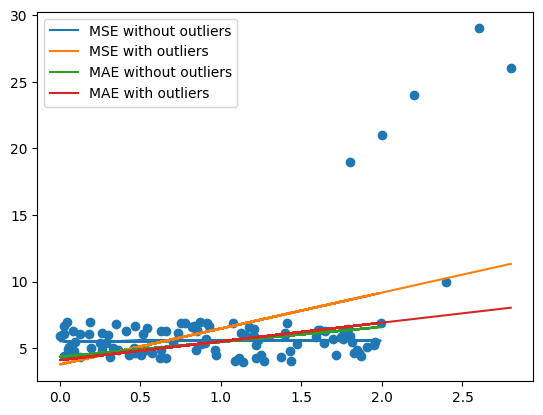

In [6]:
plt.scatter(X_out,y_out)
plt.plot(X, w_mse*X+b_mse, label='MSE without outliers')
plt.plot(X_out, w_mse_out*X_out+b_mse_out, label='MSE with outliers')
plt.plot(X, w_mae*X+b_mae, label='MAE without outliers')
plt.plot(X_out, w_mae_out*X_out+b_mae_out, label='MAE with outliers')
plt.legend()
plt.show()

In [7]:
print("MSE without outliers : ",mse(y,w_mse*X+b_mse))
print("MSE with outliers : ",mse(y,w_mse_out*X+b_mse_out))
print("MAE without outliers : ",mae(y,w_mae*X+b_mae))
print("MAE without outliers : ",mae(y,w_mae_out*X+b_mae_out))

MSE without outliers :  0.7583277977584767
MSE with outliers :  3.9608730034580826
MAE without outliers :  0.9362029591502945
MAE without outliers :  1.0237031223835318


##Problem 2 - Polynomial Regression

In [8]:
X = np.linspace(-3,3,100).reshape(-1,1)
y = 0.5*X**3 - X**2 + 2 + np.random.rand(100,1)

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_val,y_train,y_val = train_test_split(X,y,train_size=0.7)

In [11]:
def poly_features(X, degree):
  return np.hstack([X**i for i in range(1, degree+1)])

In [12]:
train_errors, val_errors = [], []
plt.figure(figsize=(12,8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

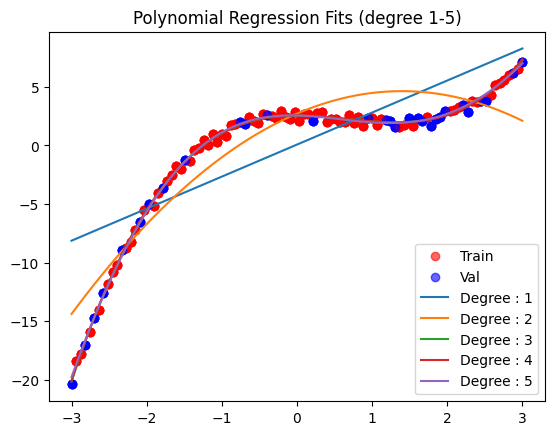

In [13]:
for d in range(1,6):
  Xp_train = poly_features(X_train,d)
  Xp_val = poly_features(X_val,d)

  Xb_train = np.c_[np.ones((len(Xp_train),1)),Xp_train]
  Xb_val = np.c_[np.ones((len(Xp_val),1)),Xp_val]

  theta = np.linalg.inv(Xb_train.T @ Xb_train) @ (Xb_train.T @ y_train)

  y_train_pred = Xb_train @ theta
  y_val_pred = Xb_val @ theta

  train_mse = mse(y_train, y_train_pred)
  val_mse = mse(y_val, y_val_pred)
  train_errors.append(train_mse)
  val_errors.append(val_mse)

  X_plot = np.linspace(-3,3,100).reshape(-1,1)
  Xp_plot = poly_features(X_plot,d)
  Xb_plot = np.c_[np.ones((len(Xp_plot),1)),Xp_plot]
  y_plot = Xb_plot @ theta

  plt.scatter(X_train, y_train, color="red", alpha=0.6, label = "Train" if d==1 else "")
  plt.scatter(X_val, y_val, color="blue", alpha=0.6, label = "Val" if d==1 else "")
  plt.plot(X_plot, y_plot, label=f"Degree : {d}")

plt.title("Polynomial Regression Fits (degree 1-5)")
plt.legend()
plt.show()

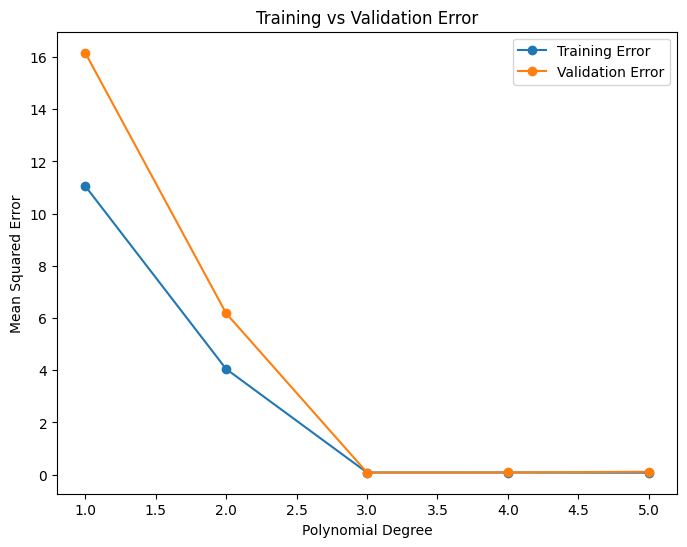

In [14]:
plt.figure(figsize=(8,6))
degrees = range(1,6)
plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, val_errors, marker='o', label="Validation Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Validation Error")
plt.legend()
plt.show()

##Problem 3 - Effect of learning rate

In [15]:
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.rand(100,1)
Xb = np.c_[np.ones((len(X),1)),X]

In [20]:
def predict(Xb, theta):
  return Xb @ theta

def gradient(Xb, y, y_pred):
  error = y - y_pred
  dtheta = (2/len(Xb)) * Xb.T @ error
  return dtheta

In [21]:
def gradient_descent(Xb, y, lr=0.01, epochs=100):
  theta = [np.zeros((Xb.shape[1],1))]
  loss_history = []

  for _ in range(epochs):
    y_pred = predict(Xb, theta)
    loss = mse(y, y_pred)
    loss_history.append(loss)
    dtheta = gradient(Xb, y, y_pred)
    theta -= lr * dtheta

  return theta, loss_history

In [22]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
epochs = 100
loss_histories = {}

for lr in learning_rates:
  _,loss_history = gradient_descent(Xb, y, lr = lr, epochs = epochs)
  loss_histories[lr] = loss_history

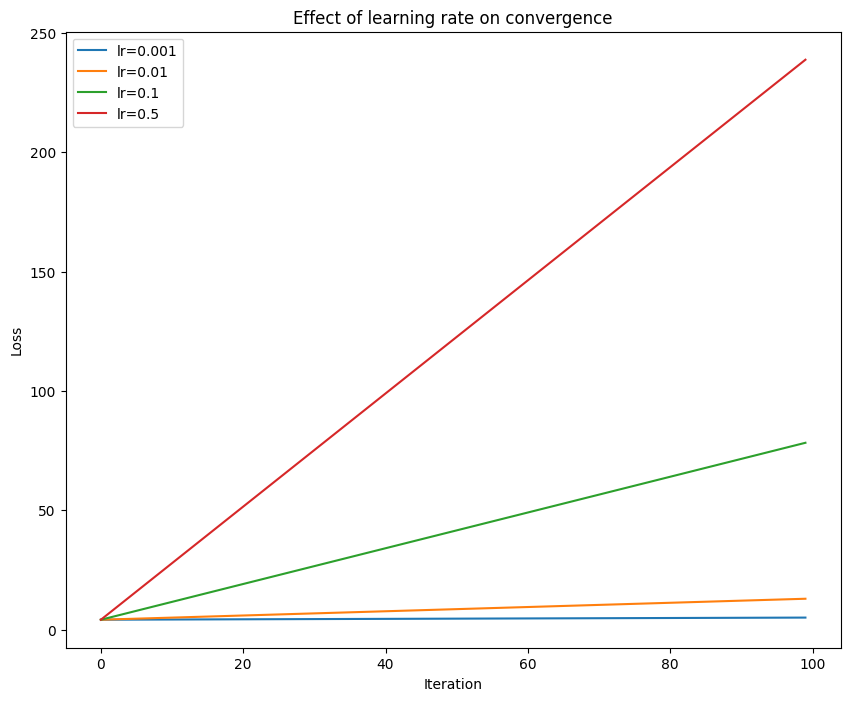

In [29]:
plt.figure(figsize=(10,8))
for lr,loss_history in loss_histories.items():
  plt.plot(range(epochs), np.log(loss_history), label=f"lr={lr}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Effect of learning rate on convergence")
plt.legend()
plt.show()